# DK ↔ EP Title Embeddings

Embed translated Danish Folketinget roll-call titles and European Parliament vote titles with `all-mpnet-base-v2`, save vectors, and inspect whether the two corpora sit close or far in embedding space.

Spec: `docs/superpowers/specs/2026-09-21-dk-ep-title-embeddings-design.md`

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd

PROJECT_DIR = Path("..")
DK_PATH = PROJECT_DIR / "data" / "temp_data" / "parliament" / "roll_calls_translated.csv"
EP_DATA_DIR = PROJECT_DIR / "EP" / "EP-data"
EP_PERIODS = ["2009-2014", "2014-2019", "2019-2024", "2024-2029"]
OUT_DIR = PROJECT_DIR / "data" / "temp_data" / "embeddings"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"
RANDOM_STATE = 42

In [4]:
df_dk = pd.read_csv(DK_PATH)
df_dk = df_dk.dropna(subset=["sag_titel_en"]).copy()
df_dk["sag_titel_en"] = df_dk["sag_titel_en"].astype(str).str.strip()
df_dk = df_dk[df_dk["sag_titel_en"].str.len() > 0].reset_index(drop=True)

print(f"DK titles: {len(df_dk):,}")
print(df_dk[["afstemningid", "sag_titel", "sag_titel_en"]].head(3))

DK titles: 2,128
   afstemningid                                          sag_titel  \
0             2  Forslag til lov om ændring af virksomhedsskatt...   
1          1783  Forslag til lov om ændring af lov om afgift af...   
2          2267  Forslag til lov om ændring af lov om produktio...   

                                        sag_titel_en  
0  Proposal for a law amending the Corporate Tax ...  
1  Proposal for a law amending the Law on the tax...  
2  Proposal for a law amending the Law on Product...  


In [5]:
ep_frames = []
for period in EP_PERIODS:
    path = EP_DATA_DIR / period / "ep_votes.csv"
    if not path.exists():
        print(f"Missing: {path}")
        continue
    df = pd.read_csv(path)
    df["period"] = period
    if "is_main" in df.columns:
        before = len(df)
        df = df[df["is_main"] == True].copy()
        print(f"{period}: {before:,} → {len(df):,} (is_main=True)")
    else:
        print(f"{period}: {len(df):,} (no is_main column; keeping all)")
    ep_frames.append(df)

df_ep = pd.concat(ep_frames, ignore_index=True)
df_ep = df_ep.dropna(subset=["display_title"]).copy()
df_ep["display_title"] = df_ep["display_title"].astype(str).str.strip()
df_ep = df_ep[df_ep["display_title"].str.len() > 0].reset_index(drop=True)

print(f"EP titles: {len(df_ep):,}")
print(df_ep[["id", "period", "display_title"]].head(3))

2009-2014: 6,961 (no is_main column; keeping all)
2014-2019: 10,252 (no is_main column; keeping all)
2019-2024: 1,808 → 1,808 (is_main=True)
2024-2029: 614 → 614 (is_main=True)
EP titles: 19,634
   id     period                                      display_title
0   1  2009-2014  Election of the President of the European Comm...
1   2  2009-2014  Agreement EC/Mongolia on certain aspects of ai...
2   3  2009-2014  EC-China agreement: maritime transport operati...


## Task 2: Encode titles and save embeddings + meta

In [6]:
dk_npy = OUT_DIR / "dk_title_embeddings.npy"
ep_npy = OUT_DIR / "ep_title_embeddings.npy"

if dk_npy.exists() and ep_npy.exists():
    print(f"Loading saved embeddings from {OUT_DIR.resolve()}")
    dk_emb = np.load(dk_npy)
    ep_emb = np.load(ep_npy)
else:
    from sentence_transformers import SentenceTransformer

    model = SentenceTransformer(MODEL_NAME)

    dk_texts = df_dk["sag_titel_en"].tolist()
    ep_texts = df_ep["display_title"].tolist()

    dk_emb = model.encode(
        dk_texts,
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    ep_emb = model.encode(
        ep_texts,
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True,
    )

    dk_emb = np.asarray(dk_emb, dtype=np.float32)
    ep_emb = np.asarray(ep_emb, dtype=np.float32)

print(MODEL_NAME)
print(f"DK embeddings: {dk_emb.shape}")
print(f"EP embeddings: {ep_emb.shape}")
assert dk_emb.shape[0] == len(df_dk)
assert ep_emb.shape[0] == len(df_ep)
assert np.allclose(np.linalg.norm(dk_emb, axis=1), 1.0, atol=1e-3)
assert np.allclose(np.linalg.norm(ep_emb, axis=1), 1.0, atol=1e-3)

Loading saved embeddings from /Users/jonashansen/Documents/GitHub/Danish-politics-project/data/temp_data/embeddings
sentence-transformers/all-mpnet-base-v2
DK embeddings: (2128, 768)
EP embeddings: (19634, 768)


In [7]:
dk_meta_cols = [c for c in ["afstemningid", "sag_titel", "sag_titel_en", "dato"] if c in df_dk.columns]
ep_meta_cols = [c for c in ["id", "period", "display_title", "timestamp", "procedure_reference"] if c in df_ep.columns]

df_dk[dk_meta_cols].to_csv(OUT_DIR / "dk_title_meta.csv", index=False)
df_ep[ep_meta_cols].to_csv(OUT_DIR / "ep_title_meta.csv", index=False)
np.save(OUT_DIR / "dk_title_embeddings.npy", dk_emb)
np.save(OUT_DIR / "ep_title_embeddings.npy", ep_emb)

print(f"Wrote artifacts to {OUT_DIR.resolve()}")
for name in [
    "dk_title_embeddings.npy",
    "dk_title_meta.csv",
    "ep_title_embeddings.npy",
    "ep_title_meta.csv",
]:
    print(f"  {name}: {(OUT_DIR / name).stat().st_size:,} bytes")

Wrote artifacts to /Users/jonashansen/Documents/GitHub/Danish-politics-project/data/temp_data/embeddings
  dk_title_embeddings.npy: 6,537,344 bytes
  dk_title_meta.csv: 864,470 bytes
  ep_title_embeddings.npy: 60,315,776 bytes
  ep_title_meta.csv: 2,244,947 bytes


In [8]:
dk_emb_reload = np.load(OUT_DIR / "dk_title_embeddings.npy")
ep_emb_reload = np.load(OUT_DIR / "ep_title_embeddings.npy")
dk_meta_reload = pd.read_csv(OUT_DIR / "dk_title_meta.csv")
ep_meta_reload = pd.read_csv(OUT_DIR / "ep_title_meta.csv")

assert dk_emb_reload.shape == dk_emb.shape
assert ep_emb_reload.shape == ep_emb.shape
assert len(dk_meta_reload) == dk_emb.shape[0]
assert len(ep_meta_reload) == ep_emb.shape[0]
print("Reload OK")

Reload OK


## Task 3: First-look analysis — centroid, histograms, neighbors, PCA / PaCMAP

In [9]:
def l2_normalize(x: np.ndarray) -> np.ndarray:
    return x / np.linalg.norm(x, axis=-1, keepdims=True)

dk_centroid = l2_normalize(dk_emb.mean(axis=0, keepdims=True))[0]
ep_centroid = l2_normalize(ep_emb.mean(axis=0, keepdims=True))[0]
centroid_cosine = float(dk_centroid @ ep_centroid)
print(f"Cosine between DK and EP centroids: {centroid_cosine:.4f}")

Cosine between DK and EP centroids: 0.6629


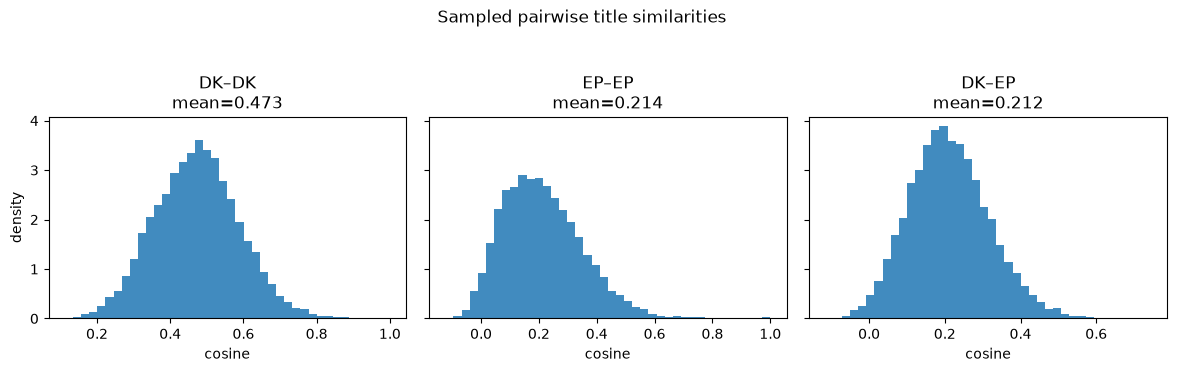

In [10]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(RANDOM_STATE)
N_PAIRS = 10_000

def sample_pair_cosines(a: np.ndarray, b: np.ndarray, n: int, rng) -> np.ndarray:
    i = rng.integers(0, len(a), size=n)
    j = rng.integers(0, len(b), size=n)
    # avoid identical indices for within-corpus samples when same matrix
    if a is b:
        same = i == j
        while same.any():
            j[same] = rng.integers(0, len(b), size=same.sum())
            same = i == j
    return (a[i] * b[j]).sum(axis=1)

cos_dk_dk = sample_pair_cosines(dk_emb, dk_emb, N_PAIRS, rng)
cos_ep_ep = sample_pair_cosines(ep_emb, ep_emb, N_PAIRS, rng)
cos_dk_ep = sample_pair_cosines(dk_emb, ep_emb, N_PAIRS, rng)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, vals, title in zip(
    axes,
    [cos_dk_dk, cos_ep_ep, cos_dk_ep],
    ["DK–DK", "EP–EP", "DK–EP"],
):
    ax.hist(vals, bins=40, density=True, alpha=0.85)
    ax.set_title(f"{title}\nmean={vals.mean():.3f}")
    ax.set_xlabel("cosine")
axes[0].set_ylabel("density")
fig.suptitle("Sampled pairwise title similarities", y=1.05)
plt.tight_layout()
plt.show()

In [11]:
def top_k_from_other(query_embs, other_embs, other_titles, query_idx, k=5):
    sims = other_embs @ query_embs[query_idx]
    top = np.argpartition(-sims, k)[:k]
    top = top[np.argsort(-sims[top])]
    return list(zip(sims[top], other_titles.iloc[top].tolist(), top.tolist()))

dk_sample_idx = rng.choice(len(df_dk), size=3, replace=False)
ep_sample_idx = rng.choice(len(df_ep), size=3, replace=False)

print("=== Random DK → top-5 EP ===")
for qi in dk_sample_idx:
    print(f"\nDK: {df_dk.loc[qi, 'sag_titel_en'][:160]}")
    for score, title, _ in top_k_from_other(dk_emb, ep_emb, df_ep["display_title"], qi, k=5):
        print(f"  {score:.3f}  {title[:140]}")

print("\n=== Random EP → top-5 DK ===")
for qi in ep_sample_idx:
    print(f"\nEP: {df_ep.loc[qi, 'display_title'][:160]}")
    for score, title, _ in top_k_from_other(ep_emb, dk_emb, df_dk["sag_titel_en"], qi, k=5):
        print(f"  {score:.3f}  {title[:140]}")

=== Random DK → top-5 EP ===

DK: Proposal for a law amending the law on sustainable biofuels and reducing greenhouse gases from transport.
  0.650  Objections pursuant to Rule 114(3): Specifying a methodology for assessing greenhouse gas emissions savings from low-carbon fuels
  0.650  Objections pursuant to Rule 114(3): Specifying a methodology for assessing greenhouse gas emissions savings from low-carbon fuels
  0.617  Objection pursuant to Rule 114(3): Trajectory to decrease the contribution of high indirect land-use change-risk biofuels, bioliquids and bi
  0.609  Objection pursuant to Rule 111(3): Feedstock for the production of biofuels and biogas
  0.586  An EU strategy to reduce methane emissions

DK: Draft law amending the law on international development cooperation. (Developing Development Policy Council and new structure for the involvement of relevant Da
  0.627  Financing instrument for development cooperation
Report on the proposal for a regulation of the European Parl

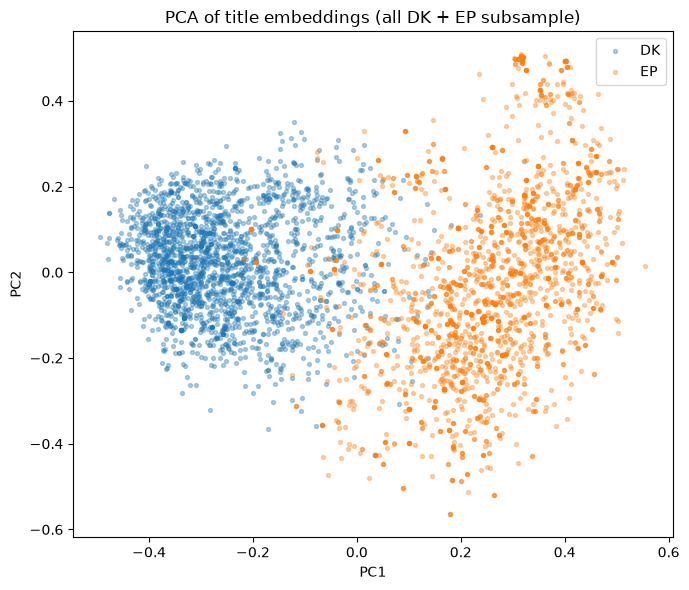

In [12]:
from sklearn.decomposition import PCA

n_dk = len(dk_emb)
ep_sample = rng.choice(len(ep_emb), size=min(n_dk, len(ep_emb)), replace=False)

X = np.vstack([dk_emb, ep_emb[ep_sample]])
labels = np.array(["DK"] * n_dk + ["EP"] * len(ep_sample))

xy = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 6))
for lab, color in [("DK", "C0"), ("EP", "C1")]:
    mask = labels == lab
    ax.scatter(xy[mask, 0], xy[mask, 1], s=8, alpha=0.35, label=lab, c=color)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA of title embeddings (all DK + EP subsample)")
ax.legend()
plt.tight_layout()
plt.show()

### PaCMAP projection

PaCMAP (same idea as in `pacmap_ANEY.ipynb`) preserves local neighborhoods and broader structure better than PCA for exploratory plots. **2D distances are not cosine similarity** — use the original embeddings for nearest-neighbor scores above.

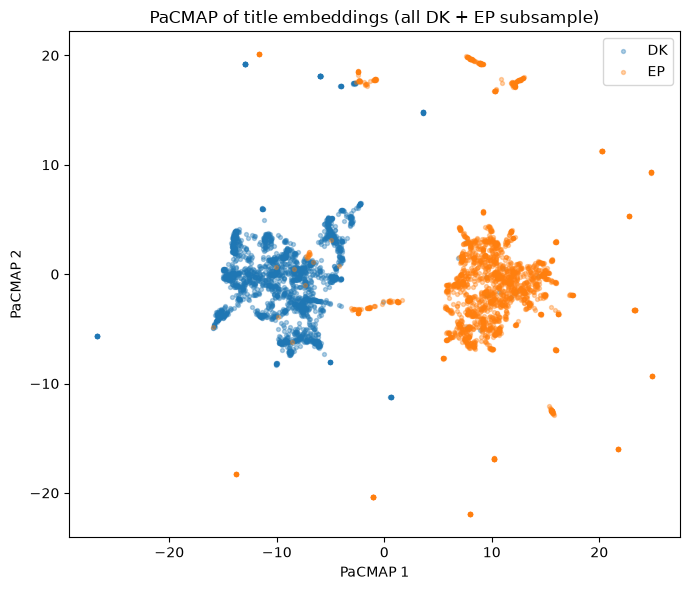

In [13]:
import pacmap

# Reuse the same balanced sample (X, labels) from the PCA cell
reducer = pacmap.PaCMAP(
    n_components=2,
    random_state=RANDOM_STATE,
)
xy_pacmap = reducer.fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 6))
for lab, color in [("DK", "C0"), ("EP", "C1")]:
    mask = labels == lab
    ax.scatter(
        xy_pacmap[mask, 0],
        xy_pacmap[mask, 1],
        s=8,
        alpha=0.35,
        label=lab,
        c=color,
    )
ax.set_xlabel("PaCMAP 1")
ax.set_ylabel("PaCMAP 2")
ax.set_title("PaCMAP of title embeddings (all DK + EP subsample)")
ax.legend()
plt.tight_layout()
plt.show()

**How to read this:** If DK–DK and EP–EP similarities are clearly higher than DK–EP, the agendas occupy somewhat different regions. Overlapping PCA/PaCMAP clouds and high DK–EP cosines suggest topical overlap in titles (not that specific votes are the same). Prefer the cosine histograms and nearest neighbors for “how close,” and treat the 2D plots as exploratory.

## Best-match similarities (not random pairs)

Random DK–EP pairs understate topical overlap: most random pairs are unrelated. More relevant: for each DK title, how close is its **best** EP neighbor (and vice versa)?

DK → best EP: mean=0.598, median=0.592, p25=0.552, p75=0.636
EP → best DK: mean=0.541, median=0.544, p25=0.479, p75=0.601


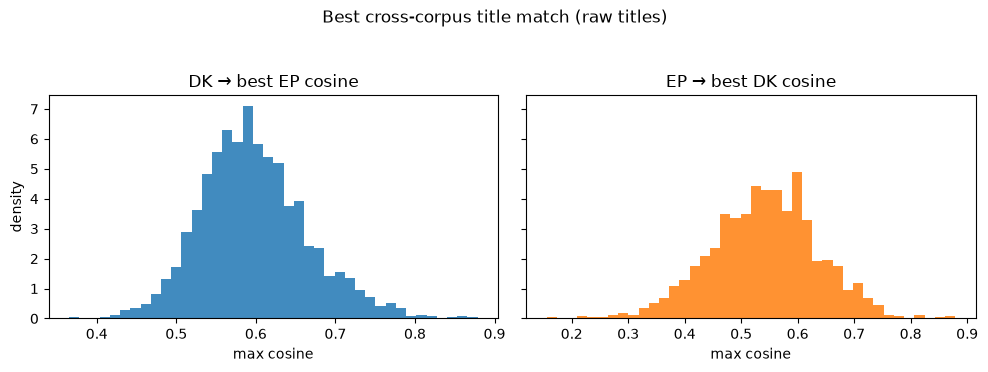


Strongest DK → EP matches:

  0.879
  DK: Proposal for a law on accessibility requirements for products and services.
  EP: Accessibility requirements for products and services

  0.864
  DK: Draft law on electronic invoicing in public procurement.
  EP: Electronic invoicing in public procurement

  0.860
  DK: Proposal for a law on insurance mediation.
  EP: Insurance mediation

  0.853
  DK: Proposal for a law on the European Union Agency for Law Enforcement Cooperation (Europol).
  EP: EU Agency for Law Enforcement Cooperation (Europol)

  0.823
  DK: Proposal for a law supplementing the regulation establishing a carbon border adjustment mechanism.
  EP: Carbon Border Adjustment Mechanism: simplification and strengthening


In [14]:
# Cosine = dot product (embeddings are L2-normalized)
sims_dk_ep = dk_emb @ ep_emb.T  # (n_dk, n_ep)

best_dk_to_ep = sims_dk_ep.max(axis=1)
best_ep_to_dk = sims_dk_ep.max(axis=0)

print(
    "DK → best EP: "
    f"mean={best_dk_to_ep.mean():.3f}, "
    f"median={np.median(best_dk_to_ep):.3f}, "
    f"p25={np.percentile(best_dk_to_ep, 25):.3f}, "
    f"p75={np.percentile(best_dk_to_ep, 75):.3f}"
)
print(
    "EP → best DK: "
    f"mean={best_ep_to_dk.mean():.3f}, "
    f"median={np.median(best_ep_to_dk):.3f}, "
    f"p25={np.percentile(best_ep_to_dk, 25):.3f}, "
    f"p75={np.percentile(best_ep_to_dk, 75):.3f}"
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
axes[0].hist(best_dk_to_ep, bins=40, density=True, alpha=0.85, color="C0")
axes[0].set_title("DK → best EP cosine")
axes[0].set_xlabel("max cosine")
axes[0].set_ylabel("density")
axes[1].hist(best_ep_to_dk, bins=40, density=True, alpha=0.85, color="C1")
axes[1].set_title("EP → best DK cosine")
axes[1].set_xlabel("max cosine")
fig.suptitle("Best cross-corpus title match (raw titles)", y=1.05)
plt.tight_layout()
plt.show()

# Show a few strong DK → EP matches
top_qi = np.argsort(-best_dk_to_ep)[:5]
print("\nStrongest DK → EP matches:")
for qi in top_qi:
    ej = int(sims_dk_ep[qi].argmax())
    print(f"\n  {best_dk_to_ep[qi]:.3f}")
    print(f"  DK: {df_dk.loc[qi, 'sag_titel_en'][:140]}")
    print(f"  EP: {df_ep.loc[ej, 'display_title'][:140]}")

## Strip DK title boilerplate, then re-embed

Most DK English titles start with “Proposal for a law amending …” / “Draft law …”. That template can pull the DK cloud away from EP. Strip those prefixes, re-encode DK, and compare best-match + PaCMAP again.

In [15]:
import re

_BOILERPLATE_PATTERNS = [
    r"^Proposal for a [Ll]aw amending (?:the )?",
    r"^Proposal for a [Ll]aw on (?:the )?",
    r"^Proposal for a [Ll]aw repealing (?:the )?",
    r"^Draft [Ll]aw amending (?:the )?",
    r"^Draft [Ll]aw on (?:the )?",
    r"^Draft [Ff]inance [Aa]ct for (?:the )?",
    r"^Draft law for Greenland on (?:the )?",
]


def strip_dk_boilerplate(text: str) -> str:
    t = str(text).strip()
    for pat in _BOILERPLATE_PATTERNS:
        t2 = re.sub(pat, "", t, count=1)
        if t2 != t:
            t = t2
            break
    t = t.strip(" .")
    # Capitalize first letter if we stripped a prefix
    if t and t[0].islower():
        t = t[0].upper() + t[1:]
    return t if t else str(text).strip()


df_dk["sag_titel_en_stripped"] = df_dk["sag_titel_en"].map(strip_dk_boilerplate)

changed = (df_dk["sag_titel_en_stripped"] != df_dk["sag_titel_en"]).sum()
print(f"Stripped boilerplate on {changed:,} / {len(df_dk):,} DK titles")
print("\nExamples:")
for i in range(5):
    print(f"  before: {df_dk.loc[i, 'sag_titel_en'][:110]}")
    print(f"  after:  {df_dk.loc[i, 'sag_titel_en_stripped'][:110]}\n")

Stripped boilerplate on 2,128 / 2,128 DK titles

Examples:
  before: Proposal for a law amending the Corporate Tax Act and the Law on withholding tax. (Action against unintended e
  after:  Corporate Tax Act and the Law on withholding tax. (Action against unintended exploitation of the corporate sch

  before: Proposal for a law amending the Law on the tax of electricity, the Law on the tax of coal, lignite and coke, t
  after:  Law on the tax of electricity, the Law on the tax of coal, lignite and coke, the Act on the tax of persons and

  before: Proposal for a law amending the Law on Production Schools.
  after:  Law on Production Schools

  before: Draft law on Danish tourism.
  after:  Danish tourism

  before: Proposal for a law amending the Act on Active Social Policy (change of property and deduction rules for post-p
  after:  Act on Active Social Policy (change of property and deduction rules for post-payment of public and other publi



In [16]:
from sentence_transformers import SentenceTransformer

stripped_path = OUT_DIR / "dk_title_embeddings_stripped.npy"

if stripped_path.exists():
    print(f"Loading stripped DK embeddings from {stripped_path}")
    dk_emb_stripped = np.load(stripped_path)
else:
    model = SentenceTransformer(MODEL_NAME)
    dk_emb_stripped = model.encode(
        df_dk["sag_titel_en_stripped"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    dk_emb_stripped = np.asarray(dk_emb_stripped, dtype=np.float32)
    np.save(stripped_path, dk_emb_stripped)
    print(f"Saved {stripped_path}")

assert dk_emb_stripped.shape == dk_emb.shape
print(f"Stripped DK embeddings: {dk_emb_stripped.shape}")

Loading stripped DK embeddings from ../data/temp_data/embeddings/dk_title_embeddings_stripped.npy
Stripped DK embeddings: (2128, 768)


Best-match means:
  raw DK → EP:      0.598
  stripped DK → EP: 0.597
  raw EP → DK:      0.541
  stripped EP → DK: 0.556


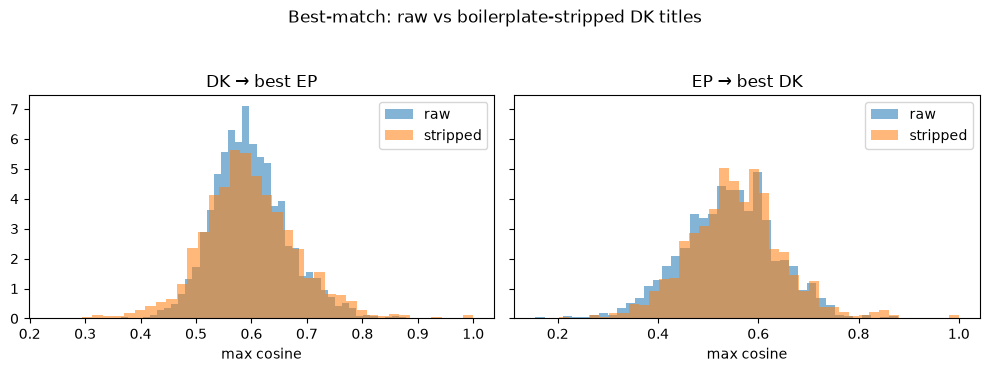

Centroid cosine (stripped DK vs EP): 0.7208
Centroid cosine (raw DK vs EP):      0.6629


In [17]:
sims_stripped = dk_emb_stripped @ ep_emb.T
best_dk_to_ep_stripped = sims_stripped.max(axis=1)
best_ep_to_dk_stripped = sims_stripped.max(axis=0)

print("Best-match means:")
print(f"  raw DK → EP:      {best_dk_to_ep.mean():.3f}")
print(f"  stripped DK → EP: {best_dk_to_ep_stripped.mean():.3f}")
print(f"  raw EP → DK:      {best_ep_to_dk.mean():.3f}")
print(f"  stripped EP → DK: {best_ep_to_dk_stripped.mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
axes[0].hist(best_dk_to_ep, bins=40, density=True, alpha=0.55, label="raw")
axes[0].hist(best_dk_to_ep_stripped, bins=40, density=True, alpha=0.55, label="stripped")
axes[0].set_title("DK → best EP")
axes[0].set_xlabel("max cosine")
axes[0].legend()
axes[1].hist(best_ep_to_dk, bins=40, density=True, alpha=0.55, label="raw")
axes[1].hist(best_ep_to_dk_stripped, bins=40, density=True, alpha=0.55, label="stripped")
axes[1].set_title("EP → best DK")
axes[1].set_xlabel("max cosine")
axes[1].legend()
fig.suptitle("Best-match: raw vs boilerplate-stripped DK titles", y=1.05)
plt.tight_layout()
plt.show()

# Centroid cosine after stripping
dk_c = l2_normalize(dk_emb_stripped.mean(axis=0, keepdims=True))[0]
ep_c = l2_normalize(ep_emb.mean(axis=0, keepdims=True))[0]
print(f"Centroid cosine (stripped DK vs EP): {float(dk_c @ ep_c):.4f}")
print(f"Centroid cosine (raw DK vs EP):      {centroid_cosine:.4f}")

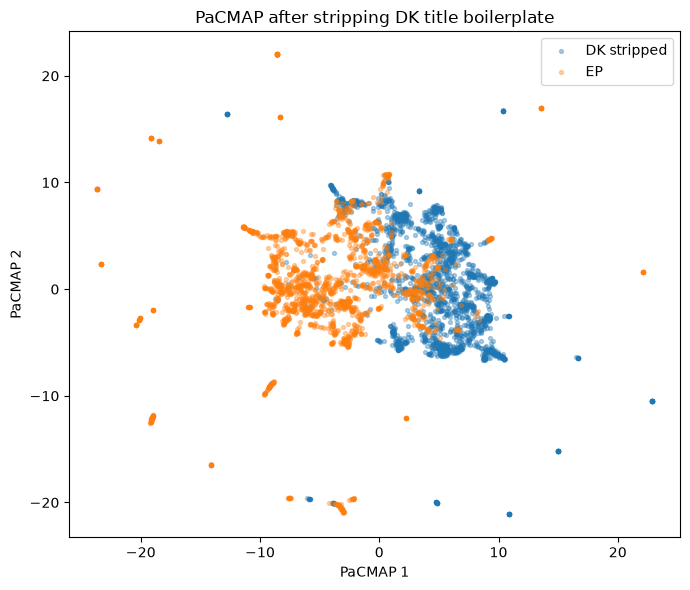

In [18]:
# PaCMAP with stripped DK titles (same EP subsample indices as PCA cell when available)
import pacmap

ep_sample_pacmap = rng.choice(len(ep_emb), size=min(len(dk_emb_stripped), len(ep_emb)), replace=False)
X_stripped = np.vstack([dk_emb_stripped, ep_emb[ep_sample_pacmap]])
labels_stripped = np.array(["DK stripped"] * len(dk_emb_stripped) + ["EP"] * len(ep_sample_pacmap))

xy_stripped = pacmap.PaCMAP(n_components=2, random_state=RANDOM_STATE).fit_transform(X_stripped)

fig, ax = plt.subplots(figsize=(7, 6))
for lab, color in [("DK stripped", "C0"), ("EP", "C1")]:
    mask = labels_stripped == lab
    ax.scatter(
        xy_stripped[mask, 0],
        xy_stripped[mask, 1],
        s=8,
        alpha=0.35,
        label=lab,
        c=color,
    )
ax.set_xlabel("PaCMAP 1")
ax.set_ylabel("PaCMAP 2")
ax.set_title("PaCMAP after stripping DK title boilerplate")
ax.legend()
plt.tight_layout()
plt.show()

## Longer EP text: `display_title` + `procedure_title`

The EP `description` column is **not** a topical summary — it is mostly French procedural labels (`Résolution`, `Proposition de résolution`, …). The useful longer field is `procedure_title` (available mainly for 2019+). Below we embed `display_title`, and append `procedure_title` when it exists and differs, then compare best-match scores to title-only EP embeddings.

In [19]:
def ep_longer_text(row) -> str:
    title = str(row.get("display_title", "") or "").strip()
    proc = str(row.get("procedure_title", "") or "").strip()
    if proc.lower() in {"", "nan", "none"}:
        return title
    if proc.lower() == title.lower():
        return title
    return f"{title} | {proc}"


df_ep["ep_text_long"] = df_ep.apply(ep_longer_text, axis=1)
longer_than_title = df_ep["ep_text_long"] != df_ep["display_title"].astype(str).str.strip()
print(
    f"EP rows with extra procedure_title text: "
    f"{longer_than_title.sum():,} / {len(df_ep):,} "
    f"({longer_than_title.mean():.1%})"
)
print("\nExamples:")
for i in df_ep.index[longer_than_title][:5]:
    print(f"  title: {df_ep.loc[i, 'display_title'][:100]}")
    print(f"  long:  {df_ep.loc[i, 'ep_text_long'][:140]}\n")

EP rows with extra procedure_title text: 828 / 19,634 (4.2%)

Examples:
  title: European Central Bank - annual report 2020
  long:  European Central Bank - annual report 2020 | European Central Bank – annual report 2020

  title: Implementation of the Anti-Trafficking Directive
  long:  Implementation of the Anti-Trafficking Directive | Implementation of Directive 2011/36/EU on preventing and combating trafficking in human b

  title: Implementation of Article 43 of the Asylum Procedures Directive
  long:  Implementation of Article 43 of the Asylum Procedures Directive | Implementation report on Article 43 of Directive 2013/32/EU on common proc

  title: Establishing the Recovery and Resilience Facility
  long:  Establishing the Recovery and Resilience Facility | Recovery and Resilience Facility

  title: Slot utilisation rules at Union airports: temporary relief
  long:  Slot utilisation rules at Union airports: temporary relief | Temporary relief from the slot utilisation rules at C

In [20]:
from sentence_transformers import SentenceTransformer

ep_long_path = OUT_DIR / "ep_title_embeddings_long.npy"

if ep_long_path.exists():
    print(f"Loading longer EP embeddings from {ep_long_path}")
    ep_emb_long = np.load(ep_long_path)
else:
    model = SentenceTransformer(MODEL_NAME)
    ep_emb_long = model.encode(
        df_ep["ep_text_long"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    ep_emb_long = np.asarray(ep_emb_long, dtype=np.float32)
    np.save(ep_long_path, ep_emb_long)
    print(f"Saved {ep_long_path}")

assert ep_emb_long.shape == ep_emb.shape
print(f"Longer EP embeddings: {ep_emb_long.shape}")

Loading longer EP embeddings from ../data/temp_data/embeddings/ep_title_embeddings_long.npy
Longer EP embeddings: (19634, 768)


DK → best EP (mean / median):
  title-only: 0.598 / 0.592
  longer EP:  0.598 / 0.593
EP → best DK (mean / median):
  title-only: 0.541 / 0.544
  longer EP:  0.542 / 0.544
Share DK→EP > 0.5: title=94.7%  long=94.7%
Share DK→EP > 0.6: title=44.7%  long=45.1%


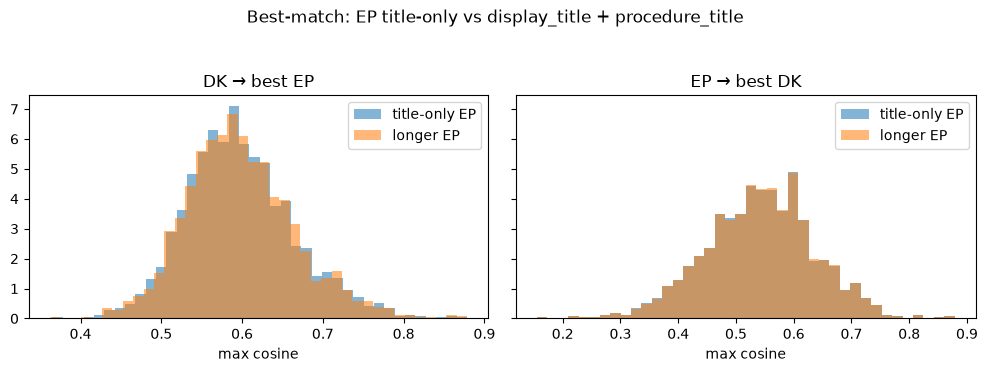


Among the 828 EP rows with extra procedure text — DK→best mean title=0.533 vs long=0.539


In [21]:
# Compare best-match: raw DK titles vs title-only EP and longer EP text
sims_title = dk_emb @ ep_emb.T
sims_long = dk_emb @ ep_emb_long.T

best_dk_title = sims_title.max(axis=1)
best_dk_long = sims_long.max(axis=1)
best_ep_title = sims_title.max(axis=0)
best_ep_long = sims_long.max(axis=0)

print("DK → best EP (mean / median):")
print(f"  title-only: {best_dk_title.mean():.3f} / {np.median(best_dk_title):.3f}")
print(f"  longer EP:  {best_dk_long.mean():.3f} / {np.median(best_dk_long):.3f}")
print("EP → best DK (mean / median):")
print(f"  title-only: {best_ep_title.mean():.3f} / {np.median(best_ep_title):.3f}")
print(f"  longer EP:  {best_ep_long.mean():.3f} / {np.median(best_ep_long):.3f}")
print(
    f"Share DK→EP > 0.5: title={ (best_dk_title > 0.5).mean():.1%}  "
    f"long={ (best_dk_long > 0.5).mean():.1%}"
)
print(
    f"Share DK→EP > 0.6: title={ (best_dk_title > 0.6).mean():.1%}  "
    f"long={ (best_dk_long > 0.6).mean():.1%}"
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
axes[0].hist(best_dk_title, bins=40, density=True, alpha=0.55, label="title-only EP")
axes[0].hist(best_dk_long, bins=40, density=True, alpha=0.55, label="longer EP")
axes[0].set_title("DK → best EP")
axes[0].set_xlabel("max cosine")
axes[0].legend()
axes[1].hist(best_ep_title, bins=40, density=True, alpha=0.55, label="title-only EP")
axes[1].hist(best_ep_long, bins=40, density=True, alpha=0.55, label="longer EP")
axes[1].set_title("EP → best DK")
axes[1].set_xlabel("max cosine")
axes[1].legend()
fig.suptitle("Best-match: EP title-only vs display_title + procedure_title", y=1.05)
plt.tight_layout()
plt.show()

# Focused check: only EP rows that actually gained procedure_title text
mask_long = (df_ep["ep_text_long"] != df_ep["display_title"].astype(str).str.strip()).to_numpy()
if mask_long.any():
    b_title_sub = sims_title[:, mask_long].max(axis=1)
    b_long_sub = sims_long[:, mask_long].max(axis=1)
    print(
        f"\nAmong the {mask_long.sum():,} EP rows with extra procedure text — "
        f"DK→best mean title={b_title_sub.mean():.3f} vs long={b_long_sub.mean():.3f}"
    )

### PaCMAP with longer EP text

Same balanced sample idea as the title-only plot: all DK titles plus an EP subsample of similar size, but EP vectors are `display_title` + `procedure_title` where that extra text exists. **2D distances are still not cosine similarity.**

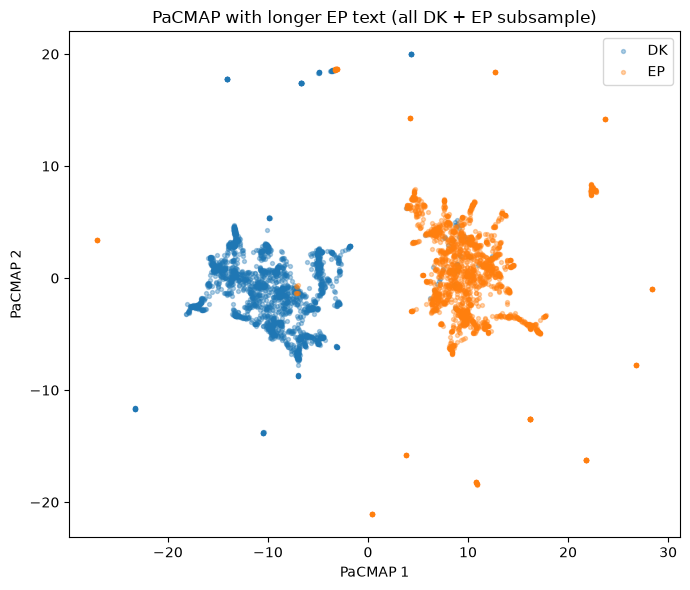

In [22]:
import pacmap

ep_sample_long = rng.choice(len(ep_emb_long), size=min(len(dk_emb), len(ep_emb_long)), replace=False)
X_long = np.vstack([dk_emb, ep_emb_long[ep_sample_long]])
labels_long = np.array(["DK"] * len(dk_emb) + ["EP"] * len(ep_sample_long))

xy_long = pacmap.PaCMAP(n_components=2, random_state=RANDOM_STATE).fit_transform(X_long)

fig, ax = plt.subplots(figsize=(7, 6))
for lab, color in [("DK", "C0"), ("EP", "C1")]:
    mask = labels_long == lab
    ax.scatter(
        xy_long[mask, 0],
        xy_long[mask, 1],
        s=8,
        alpha=0.35,
        label=lab,
        c=color,
    )
ax.set_xlabel("PaCMAP 1")
ax.set_ylabel("PaCMAP 2")
ax.set_title("PaCMAP with longer EP text (all DK + EP subsample)")
ax.legend()
plt.tight_layout()
plt.show()


### Compare the three PaCMAP projections

Same DK rows and the same EP subsample in every panel: title-only, DK boilerplate stripped, and longer EP text. Each PaCMAP is fit separately, so axes are **not** aligned across panels (rotation and scale can differ). Use this to compare cloud overlap and local structure, not specific point positions.


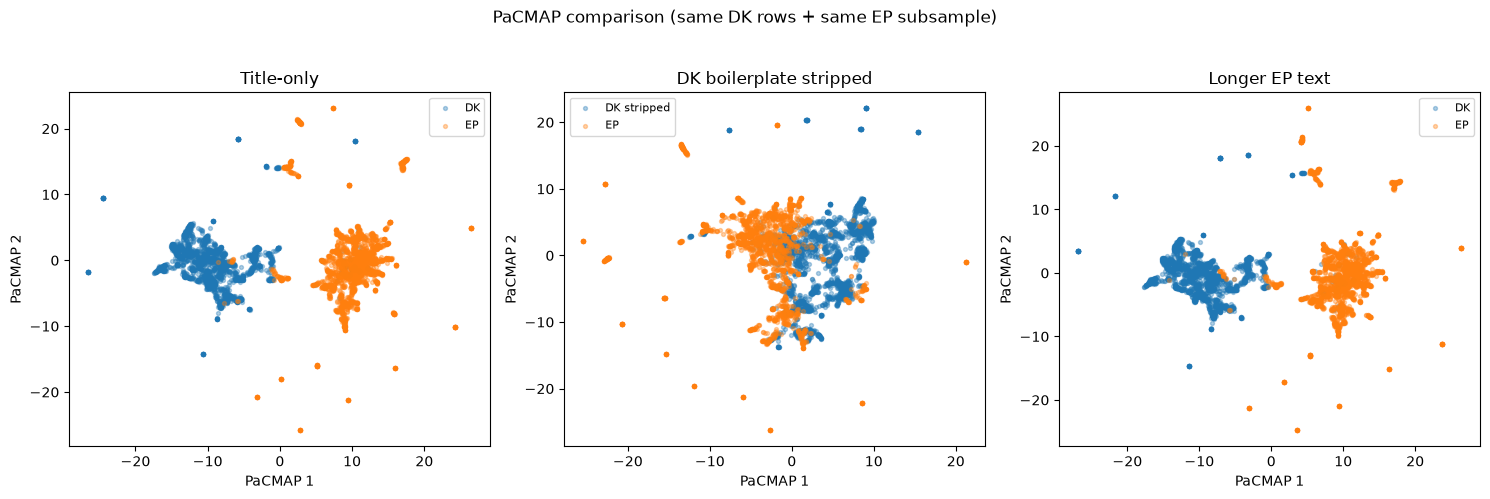

In [23]:
import pacmap

cmp_rng = np.random.default_rng(RANDOM_STATE)
n_dk = len(dk_emb)
ep_idx_cmp = cmp_rng.choice(len(ep_emb), size=min(n_dk, len(ep_emb)), replace=False)

configs = [
    ("Title-only", dk_emb, ep_emb, "DK"),
    ("DK boilerplate stripped", dk_emb_stripped, ep_emb, "DK stripped"),
    ("Longer EP text", dk_emb, ep_emb_long, "DK"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, (title, dk_x, ep_x, dk_label) in zip(axes, configs):
    X_i = np.vstack([dk_x, ep_x[ep_idx_cmp]])
    labels_i = np.array([dk_label] * len(dk_x) + ["EP"] * len(ep_idx_cmp))
    xy_i = pacmap.PaCMAP(n_components=2, random_state=RANDOM_STATE).fit_transform(X_i)
    for lab, color in [(dk_label, "C0"), ("EP", "C1")]:
        mask = labels_i == lab
        ax.scatter(
            xy_i[mask, 0],
            xy_i[mask, 1],
            s=8,
            alpha=0.35,
            label=lab,
            c=color,
        )
    ax.set_xlabel("PaCMAP 1")
    ax.set_ylabel("PaCMAP 2")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)

fig.suptitle("PaCMAP comparison (same DK rows + same EP subsample)", y=1.03)
plt.tight_layout()
plt.show()
